# Cellspots Image Analysis Pipeline

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns

## Section 1 — Processing

### Set parameters

In [2]:
OUTPUT_FOLDER = Path("../output/")

NUCLEUS_CHANNEL  = 1     # 0-based channel containing nuclei
CELL_CHANNEL     = 0     # 0-based channel containing cell signal; None to skip
SPOTS_CHANNEL    = 0
CELL_PROBA       = 0.0   # Cellpose probability threshold
DIAMETER_NUCLEUS = 40    # nucleus diameter in pixels
DIAMETER_CELL    = 100    # cell diameter in pixels

### Process a single image

Example of running the analysis programmatically on a single image.

In [3]:
IMAGE_PATH = Path("../sample_data/simulations/simulation_asym/simul_asym_0.tiff")

In [5]:
# Process a single image
from napari_cellspots._processing import process_image2D

process_image2D(
    IMAGE_PATH, OUTPUT_FOLDER,
    cell_proba=CELL_PROBA,
    cell_channel=CELL_CHANNEL,
    nucl_channel=NUCLEUS_CHANNEL,
    spot_channel=SPOTS_CHANNEL,
    diameter_nucl=DIAMETER_NUCLEUS,
    diameter_cell=DIAMETER_CELL,
)

Processing ../sample_data/simulations/simulation_asym/simul_asym_0.tiff
Segmenting cells...
Using Cellpose version 3.0.9 (major=3)
Segmenting spots...


/Users/gw18g940/Projects/Oliveira/napari-cellspots/.pixi/envs/cellspots/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA requested but not available, falling back to CPU.
INFO:spotiflow.model.spotiflow:Loading pretrained model: general
INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 3
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (500, 500)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (512, 512, 1)
INFO:spotiflow.model.spotiflow:Found 169 spots
Measuring distances from spots to cell surface...
Computing distances from spots to nuclei...
Results saved to ../output/simulation_asym


Now we can load the output for that single file:

In [8]:
cell_stats = pd.read_csv('../output/simulation_asym/simul_asym_0_statistics.csv')
cell_stats

,nucleus_id,area,cm-y,cm-x,n_spots,mean_resultant_length,circular_mean,radial_mean,anisotropy,major_axis_angle
0,1,1936.0,70.326446,235.681818,17,0.203106,5.436628,0.715751,0.904514,2.623170
1,2,1840.0,139.969565,399.308696,23,0.306247,0.917254,0.659719,0.842197,2.079433
2,3,1952.0,146.450820,242.614754,16,0.171734,5.483453,0.704060,0.869238,0.059503
3,4,1920.0,172.300000,449.433333,11,0.470223,0.614734,0.644650,0.883788,0.178457
4,5,1904.0,254.407563,218.474790,16,0.137569,6.179574,0.712181,0.911938,2.323054
5,6,1888.0,331.838983,146.889831,19,0.261248,3.887443,0.715190,0.769590,1.593515
6,7,1872.0,343.585470,82.696581,14,0.268763,4.794483,0.720788,0.956347,2.734794
7,8,1872.0,385.397436,430.286325,18,0.415116,1.260313,0.763714,0.879611,0.981824
8,9,1968.0,406.930894,151.353659,16,0.045286,0.701160,0.765437,0.903421,1.827983
9,10,1904.0,434.676471,392.289916,19,0.057444,0.331738,0.796122,0.813275,0.568930


### Process a folder

We can now process a full folder. This means all images in a given folder. Lower lever folders are not processed.

In [9]:
INPUT_FOLDER  = Path("../sample_data/simulations/simulation_asym/")       # used for folder processing

In [10]:
# Process an entire folder
from napari_cellspots._processing import process_folder2D

process_folder2D(
    INPUT_FOLDER, OUTPUT_FOLDER,
    cell_proba=CELL_PROBA,
    cell_channel=CELL_CHANNEL,
    nucl_channel=NUCLEUS_CHANNEL,
    spot_channel=SPOTS_CHANNEL,
    diameter_nucl=DIAMETER_NUCLEUS,
    diameter_cell=DIAMETER_CELL,
)

Processing ../sample_data/simulations/simulation_asym/simul_asym_0.tiff
Segmenting cells...
Using Cellpose version 3.0.9 (major=3)
Segmenting spots...
CUDA requested but not available, falling back to CPU.
INFO:spotiflow.model.spotiflow:Loading pretrained model: general
INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 3
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (500, 500)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (512, 512, 1)
INFO:spotiflow.model.spotiflow:Found 169 spots
Measuring distances from spots to cell surface...
Computing distances from spots to nuclei...
Results saved to ../output/simulation_asym
Processing ../sample_data/simulations/simulation_asym/simul_asym_1.tiff
Segmenting cells...
Using Cellpose versio

For multiple folders, just loop over them:

In [12]:
INPUT_FOLDERS  = [
    Path("../sample_data/simulations/simulation_asym/"),
        Path("../sample_data/simulations/simulation_sym/")
]

for f in INPUT_FOLDERS:
    process_folder2D(
        f,
        OUTPUT_FOLDER,
        cell_proba=CELL_PROBA,
        cell_channel=CELL_CHANNEL,
        nucl_channel=NUCLEUS_CHANNEL,
        spot_channel=SPOTS_CHANNEL,
        diameter_nucl=DIAMETER_NUCLEUS,
        diameter_cell=DIAMETER_CELL,
    )

Processing ../sample_data/simulations/simulation_asym/simul_asym_0.tiff
Segmenting cells...
Using Cellpose version 3.0.9 (major=3)
Segmenting spots...
CUDA requested but not available, falling back to CPU.
INFO:spotiflow.model.spotiflow:Loading pretrained model: general
INFO:spotiflow.model.spotiflow:Will use device: cpu
INFO:spotiflow.model.spotiflow:Predicting with prob_thresh = [0.49999999999999994], min_distance = 3
INFO:spotiflow.model.spotiflow:Peak detection mode: fast
INFO:spotiflow.model.spotiflow:Image shape (500, 500)
INFO:spotiflow.model.spotiflow:Predicting with (1, 1) tiles
INFO:spotiflow.model.spotiflow:Normalizing...
INFO:spotiflow.model.spotiflow:Padding to shape (512, 512, 1)
INFO:spotiflow.model.spotiflow:Found 169 spots
Measuring distances from spots to cell surface...
Computing distances from spots to nuclei...
Results saved to ../output/simulation_asym
Processing ../sample_data/simulations/simulation_asym/simul_asym_1.tiff
Segmenting cells...
Using Cellpose versio

---
## Section 2 — Population analysis

Now that we have analyzed multiple images, we can compute statistics and create plots:

In [4]:
from napari_cellspots._postproc import (
    load_all_spots,
    load_all_statistics,
    plot_polar_and_anisotropy,
)

Set the folder to process. All files detected in this folder **and subfolders** will be combined. We can load all spots information or the computed statistics with two utility functions:

In [5]:
STATS_ROOT = Path("../output/simulation_asym/")

In [6]:
all_spots, spots_files = load_all_spots(STATS_ROOT)
all_spots.head()

Found 2 spots file(s)
Total spots loaded: 319


,x,y,prob,intens,cell_index,nuclei_index,dists,r,theta,source_file,source_path,theta_corrected
0,472.705021,415.219414,0.880652,104.23321,10,10,17.691806,44.406447,1.028207,simul_asym_0.tiff,../sample_data/simulations/simulation_asym,0.459277
1,466.951865,409.900891,0.964006,114.64473,10,10,9.219544,36.767479,1.071301,simul_asym_0.tiff,../sample_data/simulations/simulation_asym,0.502371
2,459.993538,423.005071,0.986121,124.33971,10,10,14.422205,39.804204,0.689356,simul_asym_0.tiff,../sample_data/simulations/simulation_asym,0.120425
3,455.839832,421.246931,0.864779,107.08643,10,10,10.000000,35.866372,0.631135,simul_asym_0.tiff,../sample_data/simulations/simulation_asym,0.062205
4,453.002073,415.995582,0.991959,132.67070,10,10,4.472136,29.963082,0.658089,simul_asym_0.tiff,../sample_data/simulations/simulation_asym,0.089159


In [7]:
all_stats = load_all_statistics(STATS_ROOT)
all_stats.head()

Found 2 statistics file(s)


,nucleus_id,area,cm-y,cm-x,n_spots,mean_resultant_length,circular_mean,radial_mean,anisotropy,major_axis_angle,source_file
0,1,1936.0,70.326446,235.681818,17,0.203106,5.436628,0.715751,0.904514,2.623170,simul_asym_0
1,2,1840.0,139.969565,399.308696,23,0.306247,0.917254,0.659719,0.842197,2.079433,simul_asym_0
2,3,1952.0,146.450820,242.614754,16,0.171734,5.483453,0.704060,0.869238,0.059503,simul_asym_0
3,4,1920.0,172.300000,449.433333,11,0.470223,0.614734,0.644650,0.883788,0.178457,simul_asym_0
4,5,1904.0,254.407563,218.474790,16,0.137569,6.179574,0.712181,0.911938,2.323054,simul_asym_0


### Do your own plotting

Finally we can plot data. With the statistics dataframe, we can create our own plot:

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
STATS_ROOT = Path("../output/simulation_asym/")
all_spots, spots_files = load_all_spots(STATS_ROOT)
all_stats = load_all_statistics(STATS_ROOT)

Found 2 spots file(s)
Total spots loaded: 319
Found 2 statistics file(s)


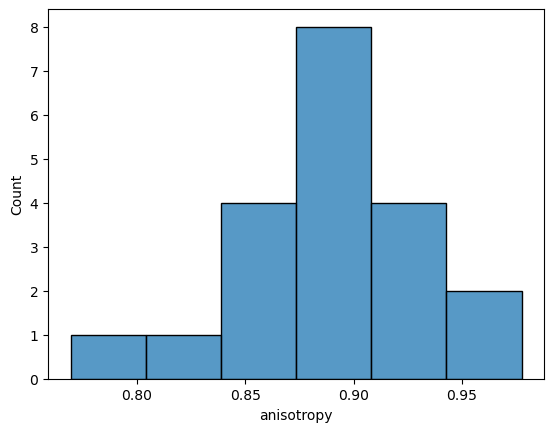

In [10]:
sns.histplot(all_stats, x='anisotropy');

In [11]:
all_spots.head(3)

,x,y,prob,intens,cell_index,nuclei_index,dists,r,theta,source_file,source_path,theta_corrected
0,472.705021,415.219414,0.880652,104.23321,10,10,17.691806,44.406447,1.028207,simul_asym_0.tiff,../sample_data/simulations/simulation_asym,0.459277
1,466.951865,409.900891,0.964006,114.64473,10,10,9.219544,36.767479,1.071301,simul_asym_0.tiff,../sample_data/simulations/simulation_asym,0.502371
2,459.993538,423.005071,0.986121,124.33971,10,10,14.422205,39.804204,0.689356,simul_asym_0.tiff,../sample_data/simulations/simulation_asym,0.120425


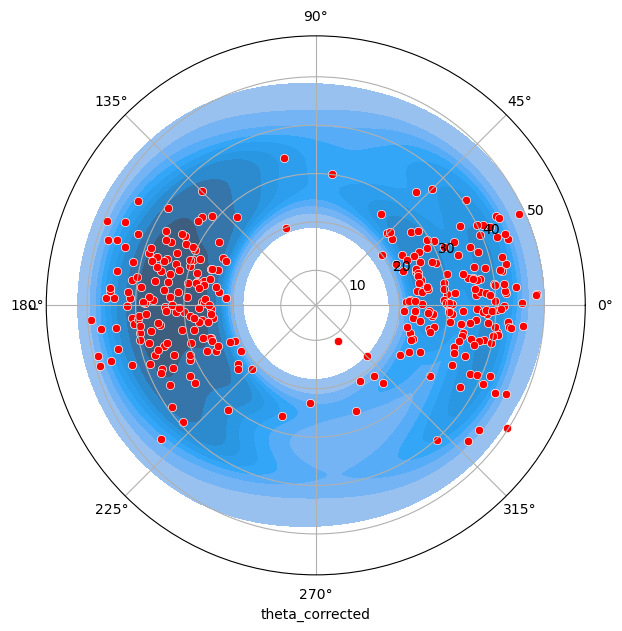

In [12]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
sns.kdeplot(all_spots, x='theta_corrected', y='r', ax=ax, fill=True)
sns.scatterplot(all_spots, x='theta_corrected', y='r', ax=ax, color='red');

We can compare two groups by importing two tables:

In [13]:
group1 = load_all_statistics("../output/simulation_asym/")
group1['type'] = 'asym'
group2 = load_all_statistics("../output/simulation_sym/")
group2['type'] = 'sym'

groups = pd.concat([group1, group2])

Found 2 statistics file(s)
Found 2 statistics file(s)


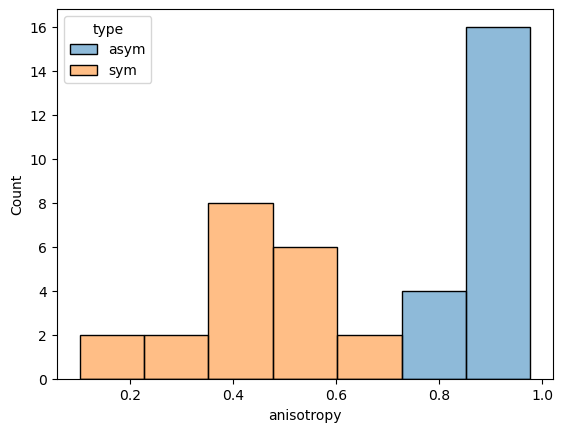

In [14]:
sns.histplot(groups, x='anisotropy', hue='type', );

### Create generic plots and save them

We can also use a utility function which plots a polar density plot of orientation and histogram of anysotropy:

Figure saved to ../output/simulation_asym/population_analysis.pdf


/Users/gw18g940/Projects/Oliveira/napari-cellspots/src/napari_cellspots/_postproc.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


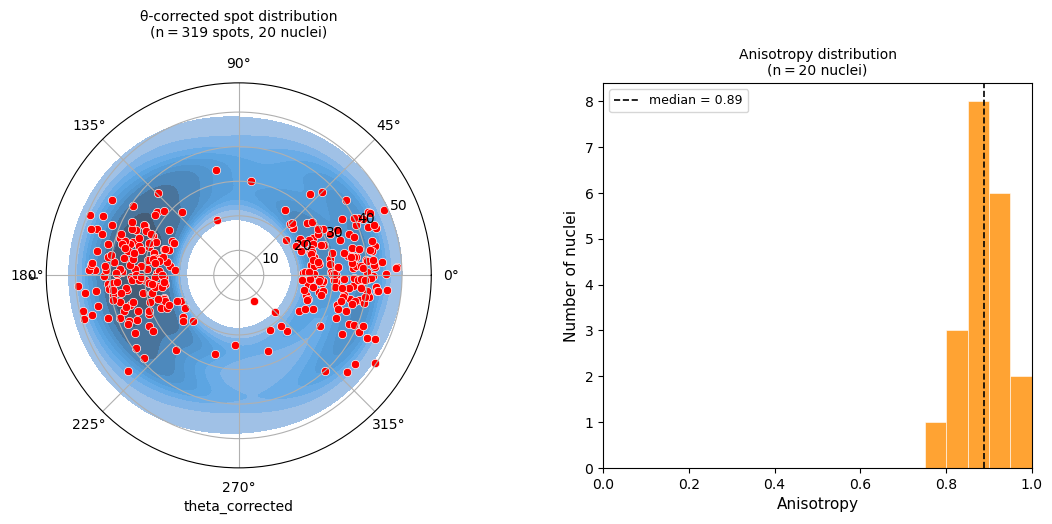

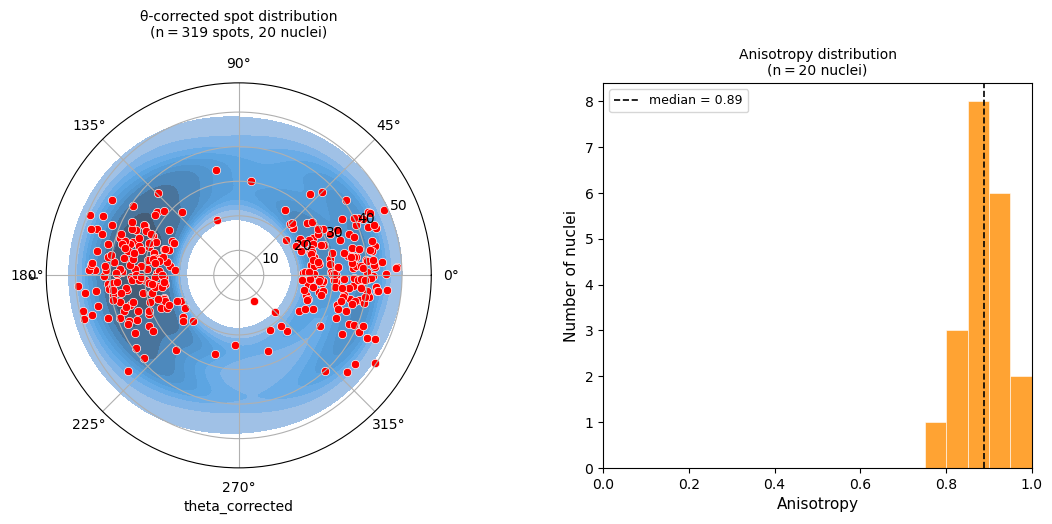

In [15]:
plot_polar_and_anisotropy(
    all_spots,
    all_stats,
    n_bins=36,
    save_path=STATS_ROOT / "population_analysis.pdf",
)